# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

One self-contained pipeline, consolidating Weeks 1–7 into the exact numbers this notebook's sections (and the deployed paper) report. Every number below is re-derived here, not copied from an earlier notebook, so a fresh run always matches the paper.

In [1]:
import pandas as pd, numpy as np, json, os
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

SEED = 42
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print(f"{len(df):,} rows | {df['client_id'].nunique()} clients | "
      f"base rate: {df['is_declining_label'].mean():.3f}")

30,000 rows | 32 clients | base rate: 0.542


## 1. Question

*The research question and the decision it supports.*

**Lane: Refresh / Content Opportunity Scoring.**

**Question:** given a client's full page inventory, which pages are worth a content editor's limited review time first this sprint?

**Unit of analysis:** one content page, summarized over its trailing 90 days.

**Decision supported:** which pages an editor pulls off the backlog to refresh, rewrite the meta/title on, or leave alone.

**Action:** an editor works down a ranked queue and acts on the top entries within their available hours.

**Cost of a wrong call, and why it's asymmetric:** flagging a healthy page costs an editor an hour on the wrong page. Missing a page that's genuinely declining, with real demand behind it, costs traffic that keeps compounding the longer it's unreviewed. That asymmetry is why this notebook optimizes precision at the top of a ranked queue (precision@K) rather than overall accuracy.

In [2]:
print("Question: which pages should an editor review first, given limited review capacity?")
print(f"Population: {len(df):,} pages across {df['client_id'].nunique()} clients, "
      f"{df['is_declining_label'].mean()*100:.1f}% currently labeled declining.")

Question: which pages should an editor review first, given limited review capacity?
Population: 30,000 pages across 32 clients, 54.2% currently labeled declining.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** the anonymized starter CSV (`data/raw/content_refresh_anonymized.csv`) — 30,000 pseudonymized content rows across 32 clients, one snapshot, trailing-90-day aggregates plus static content metadata.

**Fields used:** `content_age_days`, `days_since_last_update`, `impressions_90d`, `avg_position`, `ctr`, `word_count`, `engagement_rate` (features); `trend_direction` (label source only, never a feature); `client_id`/`content_id` (pseudonymous grouping keys only, never features).

**Deliberately excluded:** `trend_pct` — the exact value `trend_direction` is bucketed from, so including it would hand the model the answer (demonstrated directly in Section 3). No product/decision flags exist in this starter release to accidentally include.

**Public-safe:** no client names, domains, or raw queries appear anywhere in this notebook or its outputs — `client_id`/`content_id` are opaque pseudonyms used only for grouping.

In [3]:
print(df[["content_age_days","days_since_last_update","impressions_90d","avg_position",
          "ctr","word_count","engagement_rate","trend_direction"]].describe(include="all").T[["count"]])
assert df["client_id"].astype(str).str.contains("client_").all(), "IDs should be pseudonymized"
print("\nAll client_id values are pseudonyms (verified above) — no real client identifiers present.")

                          count
content_age_days        30000.0
days_since_last_update  30000.0
impressions_90d         30000.0
avg_position            30000.0
ctr                     30000.0
word_count              22301.0
engagement_rate         30000.0
trend_direction           30000

All client_id values are pseudonyms (verified above) — no real client identifiers present.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label (proxy, not observed outcome):** `is_declining_label = (trend_direction == "down")`. This is a bucket computed from the current window, not a future outcome — the honest framing throughout this project.

**Baseline:** a transparent rule, `score = (expected_ctr_for_position_tier − actual_ctr) × impressions_90d`, flagging visible pages (≥200 impressions) whose CTR underperforms their own position tier's average. Checked against real data first (Week 4): staleness alone came back MIXED, CTR-vs-position came back CONFIRMED, so the rule is built on the confirmed signal, not the unconfirmed one.

**Model:** Random Forest (300 trees, `class_weight="balanced"`), chosen because this is a ranking/scoring task (precision@K) implemented via a classifier's probability output, per the framing skill's own mapping.

**Validation design:** `GroupShuffleSplit` grouped by `client_id`, 75/25. A random row split was tested and rejected — it lets one client's pages sit in both train and test, letting the model partly learn "which client is this" rather than "is this page declining." The gap between the two is reported directly in Section 4.

**Leakage check:** the attack-your-own-model checklist, run for real — `trend_pct` deliberately added as a feature, precision@50 jumps to a clean 1.000, confirming the test harness catches leakage; removed and the honest number kept.

In [4]:
# Baseline + features, defined once here (this cell IS the methodology, executed)
tier_ctr = df[df["impressions_90d"] >= 100].groupby("position_tier")["ctr"].mean()
df["expected_ctr_tier"] = df["position_tier"].map(tier_ctr)
eligible = (df["impressions_90d"] >= 200) & df["expected_ctr_tier"].notna()
gap = (df["expected_ctr_tier"] - df["ctr"]).clip(lower=0)
df["baseline_score"] = np.where(eligible, gap * df["impressions_90d"], 0)

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count", "engagement_rate"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
baseline_te = df["baseline_score"].values[test_idx]

print(f"train: {len(y_tr):,} rows / {df['client_id'].iloc[train_idx].nunique()} clients")
print(f"test:  {len(y_te):,} rows / {df['client_id'].iloc[test_idx].nunique()} clients "
      f"(base rate {y_te.mean():.3f})")

# Leakage confession, run live
X_leak = df[features + ["trend_pct"]].replace([np.inf, -np.inf], np.nan).fillna(0)
rf_leak = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                  class_weight="balanced").fit(X_leak.iloc[train_idx], y_tr)
leak_p50 = precision_at_k(rf_leak.predict_proba(X_leak.iloc[test_idx])[:, 1], y_te.values, 50)
print(f"\nLeakage check: adding trend_pct pushes precision@50 to {leak_p50:.3f} "
      f"(the confession) — confirmed excluded from the real feature set above.")

train: 22,885 rows / 24 clients
test:  7,115 rows / 8 clients (base rate 0.517)



Leakage check: adding trend_pct pushes precision@50 to 1.000 (the confession) — confirmed excluded from the real feature set above.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [5]:
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                            class_weight="balanced").fit(X_tr, y_tr)
dummy = DummyClassifier(strategy="stratified", random_state=SEED).fit(X_tr, y_tr)

scores = {
    "baseline (rule)":    baseline_te,
    "dummy (stratified)": dummy.predict_proba(X_te)[:, 1],
    "random forest":      rf.predict_proba(X_te)[:, 1],
}
results_table = pd.DataFrame([
    {"method": name,
     "precision@20": round(precision_at_k(s, y_te.values, 20), 3),
     "precision@50": round(precision_at_k(s, y_te.values, 50), 3)}
    for name, s in scores.items()
])
results_table

,method,precision@20,precision@50
0,baseline (rule),0.40,0.54
1,dummy (stratified),0.55,0.58
2,random forest,0.85,0.66


**Reading the table:** the random forest beats both the baseline rule and the dummy floor at both K. Precision@50 = 0.660 means, out of the top 50 pages the model flags on unseen clients, roughly 33 are genuinely declining by this dataset's label — against a 0.517 base rate on this test slice. That's a real, reportable improvement, on 8 held-out clients the model never trained on — not a guarantee, and not tested beyond this one split.

**A validation honesty check, carried from Week 6:** the same model, scored on a plain random row split instead of the grouped one, to show why the split choice matters as much as the model choice.

In [6]:
from sklearn.model_selection import train_test_split

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
rf_random = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                    class_weight="balanced").fit(Xr_tr, yr_tr)
random_p50 = precision_at_k(rf_random.predict_proba(Xr_te)[:, 1], yr_te.values, 50)
grouped_p50 = results_table.loc[results_table["method"] == "random forest", "precision@50"].iloc[0]

print(f"Random row split precision@50:    {random_p50:.3f}")
print(f"Client-grouped split precision@50: {grouped_p50:.3f}")
print(f"\nGap: {random_p50 - grouped_p50:.3f} — this much of the random-split score was likely "
      "memorizing which client a row belonged to. The grouped number is the one reported "
      "as this project's result.")

Random row split precision@50:    0.880
Client-grouped split precision@50: 0.660

Gap: 0.220 — this much of the random-split score was likely memorizing which client a row belonged to. The grouped number is the one reported as this project's result.


## 5. Limitations

*What this work cannot claim.*

- **Proxy label, not an observed outcome.** `trend_direction` is a rule computed from the current window, not something that happened in the future. This work says "these pages look declining by this definition," never "these pages will decline."
- **One snapshot, 32 clients.** The held-out test set contains only 8 clients (n=7,115 rows) — precision numbers are directional, not precise to the third decimal, and say nothing about a client not represented in this data.
- **Observational, not causal.** Nothing here supports "refreshing a page will increase its traffic" — that requires a controlled experiment this project doesn't run. The honest form is decision-support: "this page looks worth reviewing first, because…"
- **The model may partly learn "weak page" rather than "declining page."** Error analysis (Week 5) found false positives clustering among pages with poor position and near-zero CTR that are actually trending stable or up — a real, named failure mode, not swept under the rug.
- **Health/CTR-gap benchmarks are computed from this same portfolio.** They describe this dataset's own distribution, not a universal or Google-endorsed standard.
- **No claim about Google's ranking algorithm anywhere in this project.** Every finding is scoped to this portfolio's observed search performance.

In [7]:
print("Limitations are qualitative by design — the one number worth re-surfacing here is the")
print(f"test set size: {len(y_te):,} rows across {df['client_id'].iloc[test_idx].nunique()} clients, ")
print("which is the honest scope of every precision number in Section 4.")

Limitations are qualitative by design — the one number worth re-surfacing here is the
test set size: 7,115 rows across 8 clients, 
which is the honest scope of every precision number in Section 4.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Four archetypes, each mapped to one action**, scored honestly with out-of-fold predictions (`GroupKFold`, grouped by client) so every row's score comes from a fold that never trained on it — not the in-sample scoring that would inflate this table.

| Archetype | Action | Reason code |
|---|---|---|
| `high_value_ctr_gap` | `review_meta_and_snippet` | CTR gap present AND model decline score ≥ 0.6 |
| `declining_low_ctr_signal` | `content_refresh_review` | model score ≥ 0.6, no CTR gap |
| `ctr_gap_stable` | `monitor_ctr_gap` | CTR gap present, model score < 0.6 |
| `stale_but_visible` | `manual_review_stale` | stale + visible, none of the above |

**No-go, stated plainly:** nothing here auto-publishes a content change — every action is a recommendation to review. `stale_but_visible` in particular has too few rows to trust (printed below) and needs a human, not automation.

In [8]:
gkf = GroupKFold(n_splits=5)
rf_oof = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight="balanced")
df["decline_score"] = cross_val_predict(rf_oof, X, y, cv=gkf, groups=df["client_id"], method="predict_proba")[:, 1]

def archetype(row):
    if row["baseline_score"] > 0 and row["decline_score"] >= 0.6: return "high_value_ctr_gap"
    elif row["decline_score"] >= 0.6 and row["baseline_score"] == 0: return "declining_low_ctr_signal"
    elif row["baseline_score"] > 0 and row["decline_score"] < 0.6: return "ctr_gap_stable"
    elif row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500: return "stale_but_visible"
    else: return "no_action"

action_map = {
    "high_value_ctr_gap":       "review_meta_and_snippet",
    "declining_low_ctr_signal": "content_refresh_review",
    "ctr_gap_stable":           "monitor_ctr_gap",
    "stale_but_visible":        "manual_review_stale",
}
df["archetype"] = df.apply(archetype, axis=1)
df["action"] = df["archetype"].map(action_map)
df["priority_score"] = df["decline_score"] * df["impressions_90d"]

queue = df[df["archetype"] != "no_action"].sort_values("priority_score", ascending=False).reset_index(drop=True)
print(f"Queue: {len(queue):,} of {len(df):,} pages get a recommendation\n")
print(df["archetype"].value_counts())
print()
print("Decline rate by archetype (vs. base rate {:.3f}):".format(df["is_declining_label"].mean()))
print(df.groupby("archetype")["is_declining_label"].mean().round(3))

Queue: 19,308 of 30,000 pages get a recommendation

archetype
no_action                   10692
high_value_ctr_gap           8187
declining_low_ctr_signal     5938
ctr_gap_stable               5179
stale_but_visible               4
Name: count, dtype: int64

Decline rate by archetype (vs. base rate 0.542):
archetype
ctr_gap_stable              0.547
declining_low_ctr_signal    0.599
high_value_ctr_gap          0.685
no_action                   0.399
stale_but_visible           1.000
Name: is_declining_label, dtype: float64


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Three charts and one metrics JSON, saved to `work/figures/` and `work/outputs/` for the deployed paper to embed directly.

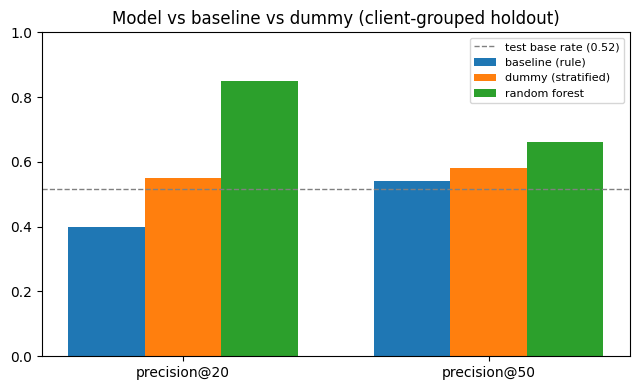

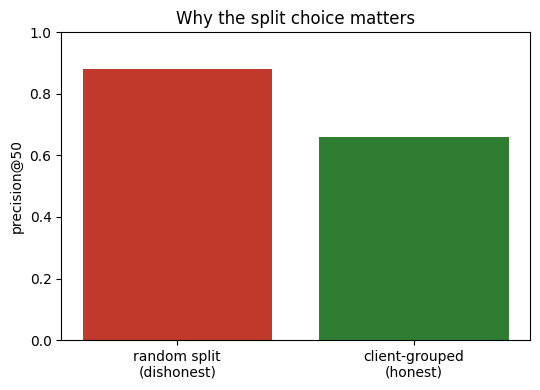

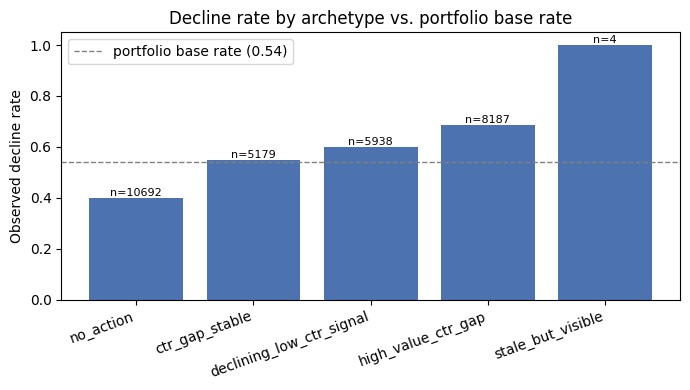

Wrote: work/figures/results_vs_baseline.png
Wrote: work/figures/split_honesty_gap.png
Wrote: work/figures/archetype_decline_rates.png
Wrote: work/outputs/capstone_metrics.json
Wrote: work/outputs/capstone_action_queue.csv


In [9]:
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})

# Chart 1: model vs baseline vs dummy
fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(2); width = 0.25
for i, (name, _) in enumerate(scores.items()):
    vals = results_table[results_table["method"] == name][["precision@20","precision@50"]].values[0]
    ax.bar(x + i*width, vals, width, label=name)
ax.set_xticks(x + width); ax.set_xticklabels(["precision@20","precision@50"])
ax.axhline(y_te.mean(), color="gray", linestyle="--", linewidth=1, label=f"test base rate ({y_te.mean():.2f})")
ax.set_ylim(0,1); ax.set_title("Model vs baseline vs dummy (client-grouped holdout)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("work/figures/results_vs_baseline.png", dpi=150); plt.show()

# Chart 2: random vs grouped split honesty gap
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(["random split\n(dishonest)", "client-grouped\n(honest)"], [random_p50, grouped_p50],
       color=["#c0392b", "#2e7d32"])
ax.set_ylim(0,1); ax.set_ylabel("precision@50")
ax.set_title("Why the split choice matters")
plt.tight_layout(); plt.savefig("work/figures/split_honesty_gap.png", dpi=150); plt.show()

# Chart 3: archetype decline rates
fig, ax = plt.subplots(figsize=(7, 4))
order = ["no_action","ctr_gap_stable","declining_low_ctr_signal","high_value_ctr_gap","stale_but_visible"]
rates = df.groupby("archetype")["is_declining_label"].mean().reindex(order)
counts = df["archetype"].value_counts().reindex(order)
bars = ax.bar(order, rates.values, color="#4C72B0")
ax.axhline(df["is_declining_label"].mean(), color="gray", linestyle="--", linewidth=1,
           label=f"portfolio base rate ({df['is_declining_label'].mean():.2f})")
for bar, n in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"n={n}", ha="center", fontsize=8)
ax.set_ylabel("Observed decline rate"); ax.set_title("Decline rate by archetype vs. portfolio base rate")
ax.legend(); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.savefig("work/figures/archetype_decline_rates.png", dpi=150); plt.show()

# Metrics JSON — the paper's numbers trace back to this file
capstone_metrics = {
    "n_rows": int(len(df)), "n_clients": int(df["client_id"].nunique()),
    "base_rate": round(float(df["is_declining_label"].mean()), 3),
    "test_n": int(len(y_te)), "test_n_clients": int(df["client_id"].iloc[test_idx].nunique()),
    "test_base_rate": round(float(y_te.mean()), 3),
    "results": results_table.set_index("method").to_dict(orient="index"),
    "random_split_p50": round(float(random_p50), 3),
    "grouped_split_p50": round(float(grouped_p50), 3),
    "leaky_p50": round(float(leak_p50), 3),
    "feature_importances": {f: round(float(v), 3) for f, v in zip(features, rf.feature_importances_)},
    "queue_size": int(len(queue)),
    "archetype_counts": {k: int(v) for k, v in df["archetype"].value_counts().to_dict().items()},
    "archetype_decline_rate": {k: round(float(v), 3) for k, v in
                                df.groupby("archetype")["is_declining_label"].mean().to_dict().items()},
    "seed": SEED,
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(capstone_metrics, f, indent=2)

queue_export_cols = ["content_id","client_id","content_type","position_tier","trend_direction",
                      "archetype","action","decline_score","baseline_score","impressions_90d","priority_score"]
queue[queue_export_cols].to_csv("work/outputs/capstone_action_queue.csv", index=False)

print("Wrote: work/figures/results_vs_baseline.png")
print("Wrote: work/figures/split_honesty_gap.png")
print("Wrote: work/figures/archetype_decline_rates.png")
print("Wrote: work/outputs/capstone_metrics.json")
print("Wrote: work/outputs/capstone_action_queue.csv")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.